# Homework 3

### Question 1
**(a)**

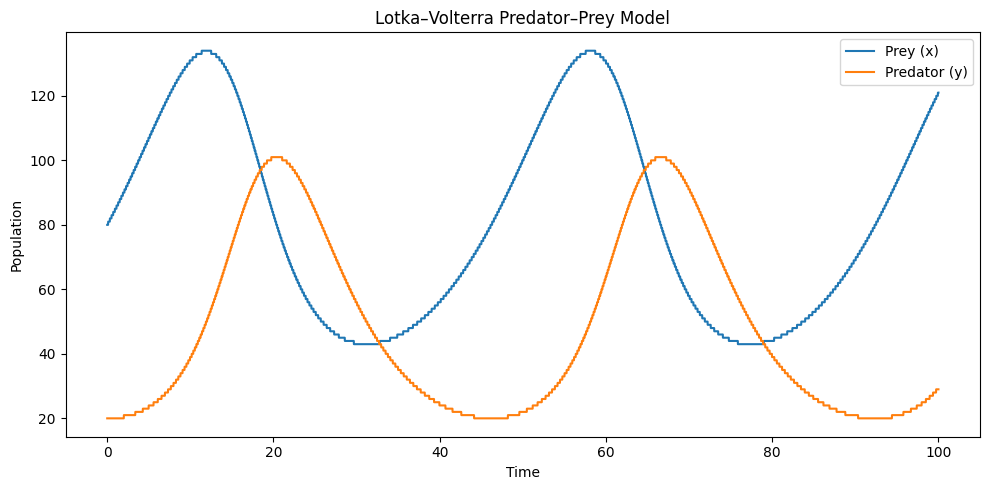

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def lotka_volterra(alpha, beta, gamma, delta, x0, y0, t0, t_end, dt):

    n_steps = int((t_end - t0) / dt) + 1

    t = np.zeros(n_steps)
    x = np.zeros(n_steps)
    y = np.zeros(n_steps)

    t[0] = t0
    x[0] = x0
    y[0] = y0

    extinction_threshold = 0.1

    for k in range(1, n_steps):
        t[k] = t[k-1] + dt

        dxdt = alpha * x[k-1] - beta * x[k-1] * y[k-1]
        dydt = -gamma * y[k-1] + delta * x[k-1] * y[k-1]

        x[k] = x[k-1] + dt * dxdt
        y[k] = y[k-1] + dt * dydt

        # avoid negative number
        x[k] = max(x[k], 0)
        y[k] = max(y[k], 0)

        # When a species becomes extinct, exit the function.
        if x[k] < extinction_threshold or y[k] < extinction_threshold:
            x[k] = 0
            y[k] = 0
            return t[:k], np.round(x[:k]).astype(int), np.round(y[:k]).astype(int)
    # return the Integer
    return t, np.round(x).astype(int), np.round(y).astype(int)


alpha = 0.1
beta = 0.002
gamma = 0.2
delta = 0.0025

x0 = 80
y0 = 20

t0 = 0
t_end = 100
dt = 0.0001   # very small step for accuracy

t, x, y = lotka_volterra(alpha, beta, gamma, delta, x0, y0, t0, t_end, dt)

# Plot
plt.figure(figsize=(10,5))
plt.plot(t, x, label="Prey (x)")
plt.plot(t, y, label="Predator (y)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Lotka–Volterra Predator–Prey Model")
plt.legend()
plt.tight_layout()
plt.show()


**(b,1)**
First, when predator mortality rates become too high to sustain, the prey population continues to grow due to the lack of natural enemies.

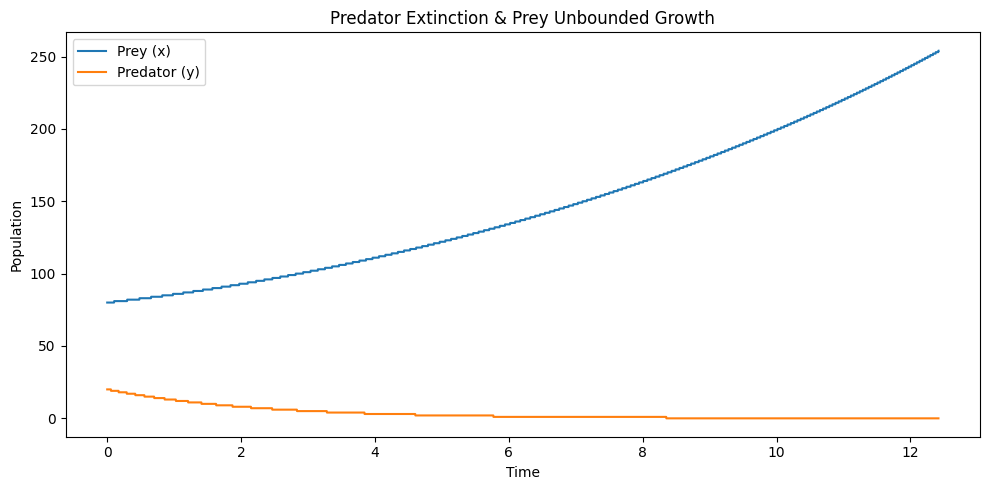

In [15]:
alpha = 0.1
beta = 0.002
gamma = 0.5
delta = 0.0005

x0 = 80
y0 = 20

t0 = 0
t_end = 100
dt = 0.0001   # very small step for accuracy

t, x, y = lotka_volterra(alpha, beta, gamma, delta, x0, y0, t0, t_end, dt)

# Plot
plt.figure(figsize=(10,5))
plt.plot(t, x, label="Prey (x)")
plt.plot(t, y, label="Predator (y)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Predator Extinction & Prey Unbounded Growth")
plt.legend()
plt.tight_layout()
plt.show()

**(b.2)**
Second, when the predator's hunting efficiency exceeds the prey's survival rate, both species will eventually face extinction.

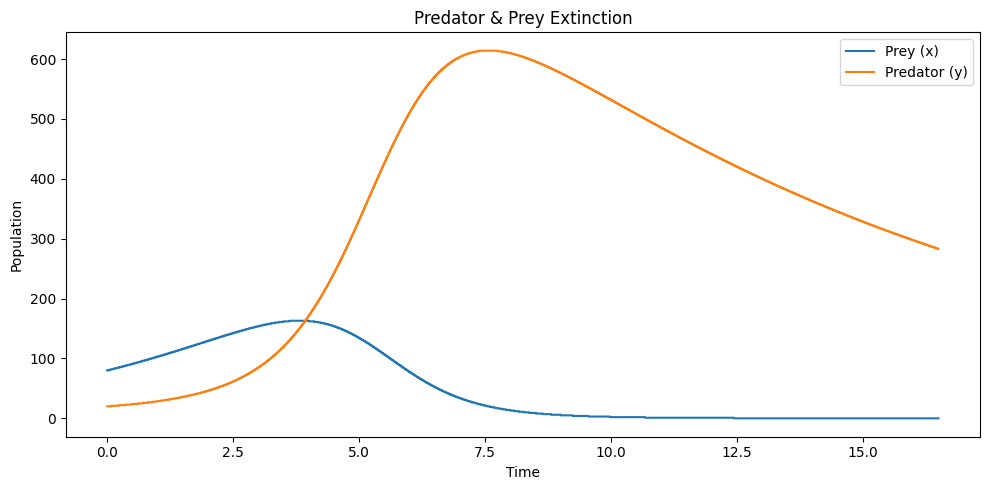

In [13]:
alpha = 0.3
beta = 0.002
gamma = 0.1
delta = 0.005

x0 = 80
y0 = 20

t0 = 0
t_end = 100
dt = 0.0001   # very small step for accuracy

t, x, y = lotka_volterra(alpha, beta, gamma, delta, x0, y0, t0, t_end, dt)

# Plot
plt.figure(figsize=(10,5))
plt.plot(t, x, label="Prey (x)")
plt.plot(t, y, label="Predator (y)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Predator & Prey Extinction")
plt.legend()
plt.tight_layout()
plt.show()

**(b.3)**
Third, when predation efficiency and production are balanced, the image will show a continuous repeating circle.

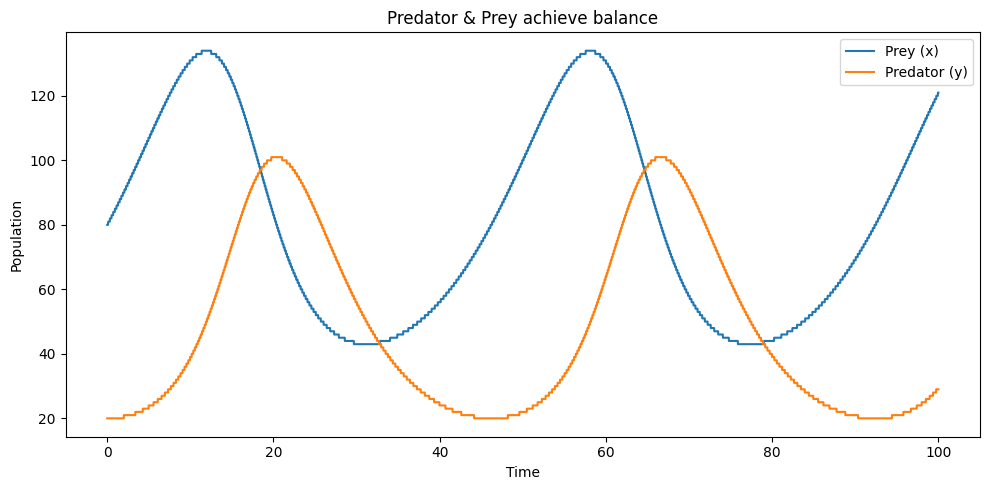

In [17]:
alpha = 0.1
beta = 0.002
gamma = 0.2
delta = 0.0025

x0 = 80
y0 = 20

t0 = 0
t_end = 100
dt = 0.0001   # very small step for accuracy

t, x, y = lotka_volterra(alpha, beta, gamma, delta, x0, y0, t0, t_end, dt)

# Plot
plt.figure(figsize=(10,5))
plt.plot(t, x, label="Prey (x)")
plt.plot(t, y, label="Predator (y)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Predator & Prey achieve balance")
plt.legend()
plt.tight_layout()
plt.show()

**(c)**
Because an increase in prey leads to an increase in predators, and an increase in predators leads to a decrease in prey, and a decrease in prey leads to a decrease in predators, this kind of delayed feedback loop of chasing and killing will continue to cycle, so the numbers show periodic changes.


In the SIS model, the system has only one unidirectional path of change: "the number of infected people increases or decreases." Everyone constantly switches between susceptible and infected states, and the population eventually reaches a stable equilibrium. Because the model lacks the predator-prey feedback mechanism where an increase in one variable lags and pushes another variable to change, the number of infected people does not experience a cycle of increase-decrease-increase, but gradually stabilizes. Therefore, the SIS model does not exhibit periodic fluctuations.

In the SIR model, because recovered individuals do not revert to being susceptible, the number of susceptible individuals continuously decreases, and the system lacks a replenishment mechanism to allow the infection to re-emerge. Therefore, there is no sustained cycle, and the epidemic only breaks out once and then declines. In the SIRS model, however, recovered individuals return to a susceptible state as their immunity declines. This feedback mechanism of susceptible individuals being continuously replenished gives the system a predator-prey cyclical condition, thus potentially leading to periodic fluctuations. Whether these fluctuations are single, damped, or sustained cycles depends on the rate of immune decline and other parameters.

### Question 2
**(a)**

In [81]:
def graph_lotka_volterra(G, alpha, beta, gamma, delta, x, y, t):
    for node in G.nodes():
        G.nodes[node]['state'] = 'empty'
    
    nodes = list(G.nodes())
    n_nodes = len(nodes)

    prey_nodes = random.sample(nodes, x)

    remaining_nodes = list(set(nodes) - set(prey_nodes))
    predator_nodes = random.sample(remaining_nodes, y)

    # Initialize graph with x and y
    for node in prey_nodes:
        G.nodes[node]['state'] = 'prey'
    for node in predator_nodes:
        G.nodes[node]['state'] = 'predator'

    def count_states(graph):
        c = {'prey': 0, 'predator': 0, 'empty': 0}
        for n in graph.nodes():
            s = graph.nodes[n]['state']
            c[s] += 1
        return c

    history = {'prey': [], 'predator': [], 'empty': []}

    # get the Initialize graph data
    c0 = count_states(G)
    history['prey'].append(c0['prey'])
    history['predator'].append(c0['predator'])
    history['empty'].append(c0['empty'])

    for _ in range(t):
        current_states = {n: G.nodes[n]['state'] for n in G.nodes()}
        new_states = current_states.copy()

        # is new prey append
        for n, state in current_states.items():
            if state != 'prey':
                continue

            if random.random() < alpha:
                empty_neighbors = [nbr for nbr in G.neighbors(n) if current_states.get(nbr) == 'empty' and new_states.get(nbr) == 'empty']
                if empty_neighbors:
                    target = random.choice(empty_neighbors)
                    new_states[target] = 'prey'

        # Use beta and gamma to determine whether prey has been preyed upon and whether it has become a new predator.
        for n, state in current_states.items():
            if state != 'prey':
                continue

            eaten = False
            # Check if any predators among the neighbors have attempted to prey on the animal.
            for nbr in G.neighbors(n):
                if current_states.get(nbr) == 'predator':
                    if random.random() < beta:
                        eaten = True
                        break

            if eaten:
                if random.random() < delta:
                    new_states[n] = 'predator'
                else:
                    new_states[n] = 'empty'

        # Finally, check if the predator is dead.
        for n, state in current_states.items():
            if state == 'predator':
                if random.random() < gamma:
                    new_states[n] = 'empty'

        # apply changes
        for n, s in new_states.items():
            G.nodes[n]['state'] = s

        # record it
        c = count_states(G)
        history['prey'].append(c['prey'])
        history['predator'].append(c['predator'])
        history['empty'].append(c['empty'])

    return history


**(b)**

<Figure size 1200x800 with 0 Axes>

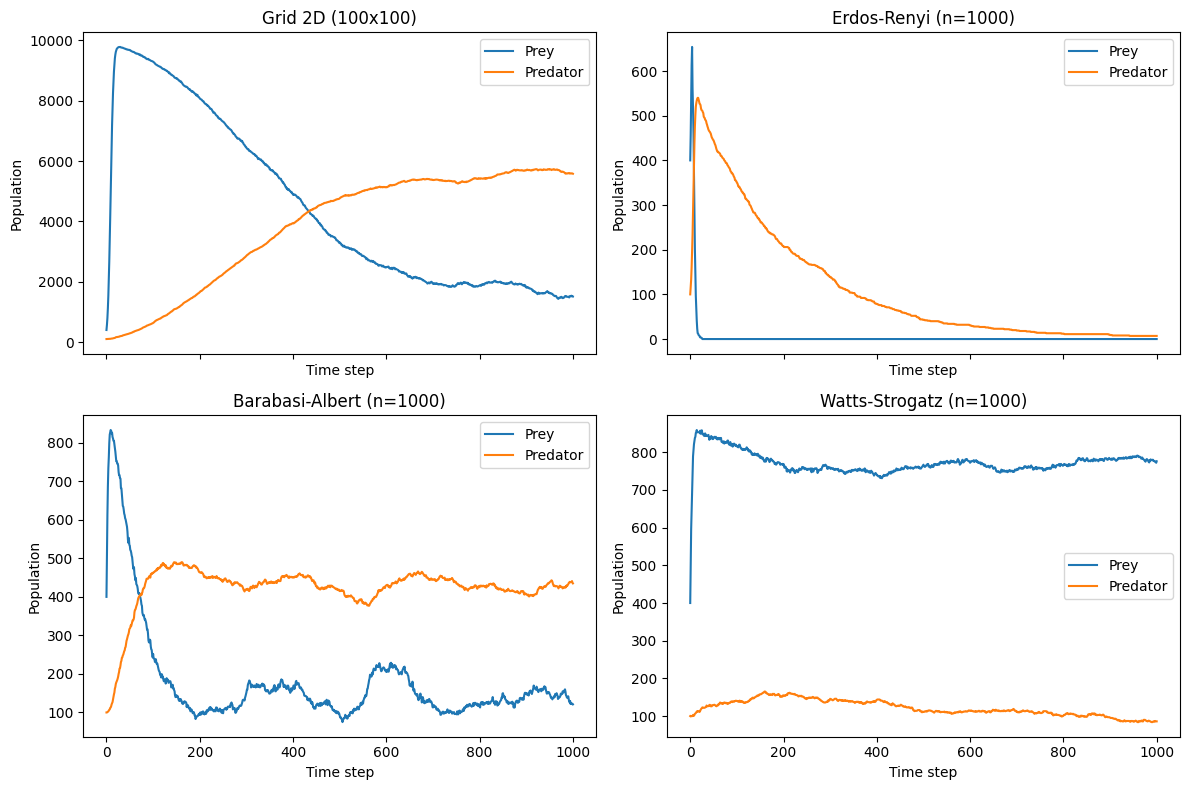

In [104]:
import random
import networkx as nx

random.seed(5)

G1 = nx.grid_2d_graph(100, 100)
G2 = nx.gnp_random_graph(1000, 0.05)
G3 = nx.barabasi_albert_graph(1000, 2)
G4 = nx.watts_strogatz_graph(1000, 2, 0.05)

alpha = 0.4
beta = 0.05
gamma = 0.005
delta = 0.2
X= 400
Y= 100
T = 1000

histories = {}
histories['Grid 2D (100x100)']       = graph_lotka_volterra(G1, alpha, beta, gamma, delta, x=X, y=Y, t=T)
histories['Erdos-Renyi (n=1000)']    = graph_lotka_volterra(G2, alpha, beta, gamma, delta, x=X, y=Y, t=T)
histories['Barabasi-Albert (n=1000)']= graph_lotka_volterra(G3, alpha, beta, gamma, delta, x=X, y=Y, t=T)
histories['Watts-Strogatz (n=1000)'] = graph_lotka_volterra(G4, alpha, beta, gamma, delta, x=X, y=Y, t=T)


plt.figure(figsize=(12, 8))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

network_names = list(histories.keys())

for idx, name in enumerate(network_names):
    history = histories[name]
    
    ax = axes[idx]
    ax.plot(history['prey'], label='Prey')
    ax.plot(history['predator'], label='Predator')
    
    ax.set_title(name)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Population')
    ax.legend()

plt.tight_layout()
plt.show()



**(c)**
By modifying the parameters, I discovered that predators typically encounter a survival crisis during initialization. Since the likelihood of prey being nearby is low at initialization, many predators die due to lack of food. This characteristic appears in all the charts.Therefore, we need an extremely low predator mortality rate; otherwise, unless the initial value of y is increased, the predators will quickly become extinct.

For Grid 2D, because each Grid only has 4 neighbors, the predator cannot spread quickly, allowing prey to reconstruct in "cavity areas" at a distance. This causes the prey population to rise rapidly → reaching near full grid (10000) → then being eaten back down to below 2000 by the predator → later slowly declining and stabilizing at around 1500–2000.

The randomized mixture of ER plots yields the following results: The probability of the predator encountering prey is equal to the global average. There is virtually no refuge. This means that even with a high α, we cannot protect the prey, because each newly formed prey is immediately captured by the predator.

In the Barabasi–Albert diagram, the prey population drops rapidly to ~100–200, followed by repeated, clear periodic fluctuations. The predator population remains stable at ~400–500, with minor oscillations.BA networks are characterized by high hub density, ensuring that predators on the hub are almost guaranteed to find prey. When prey bounces off other areas and spreads towards the hub, the predator quickly hunts again. This forms a cycle.

The Watts–Strogatz graph shows a rapid increase in prey followed by a slow decline, with the number of predators stabilizing at 150-200. Because the WS structure lies between the Grid and ER graphs, its high clustering characteristic allows prey to persist without the rapid extinction seen in the ER graph. The WS graph produces the most stable and balanced long-term coexistence state.

In [101]:
# I used snowball sampling to help us understand the distribution of specific predators and prey. This part of the code was written by AI.
def sample_nodes_snowball(G, k, start_node=None):
    """
    Snowball sampling:
    选取一个起点，将其邻居、邻居的邻居……逐层加入，
    直到节点数 >= k，或者没有新邻居可加。
    """
    nodes = list(G.nodes())
    if not nodes:
        return []

    if start_node is None:
        start_node = random.choice(nodes)

    visited = set([start_node])
    frontier = [start_node]

    while len(visited) < k and frontier:
        new_frontier = []
        for u in frontier:
            for v in G.neighbors(u):
                if v not in visited:
                    visited.add(v)
                    new_frontier.append(v)
                    if len(visited) >= k:
                        break
            if len(visited) >= k:
                break
        frontier = new_frontier

        # 如果扩展不出新节点了，就跳出
        if not frontier:
            break

    # 最后如果多了就截断一下（一般不会多很多）
    sampled = list(visited)
    if len(sampled) > k:
        sampled = sampled[:k]

    return sampled


In [102]:
def assign_states_from_history(G, history):
    """
    根据 history 最后一条记录的数量
    随机分配 prey, predator, empty 状态给所有节点。
    """

    nodes = list(G.nodes())
    random.shuffle(nodes)

    final_prey     = history['prey'][-1]
    final_predator = history['predator'][-1]
    final_empty    = history['empty'][-1]

    # 随机切片
    prey_nodes     = nodes[:final_prey]
    predator_nodes = nodes[final_prey:final_prey + final_predator]
    empty_nodes    = nodes[final_prey + final_predator:]

    state = {}

    for n in prey_nodes:
        state[n] = "prey"
    for n in predator_nodes:
        state[n] = "predator"
    for n in empty_nodes:
        state[n] = "empty"

    return state


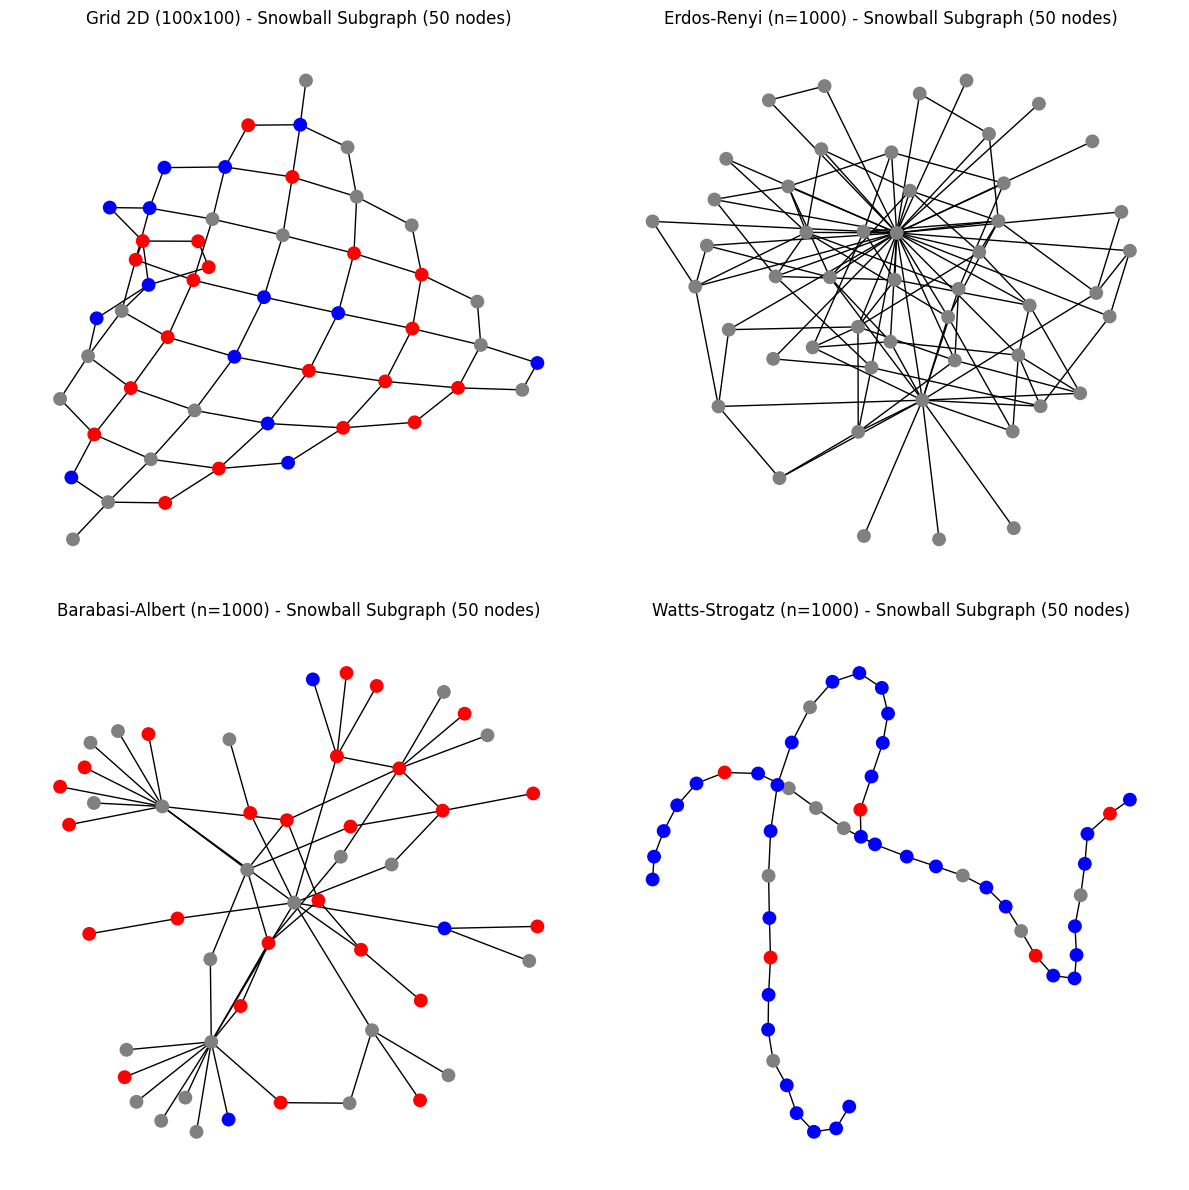

In [103]:
import matplotlib.pyplot as plt

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 12))
axes2 = axes2.flatten()

network_names = list(histories.keys())

for idx, name in enumerate(network_names):
    history = histories[name]

    # 重新构造对应拓扑（只要结构，不要动态）
    if name == 'Grid 2D (100x100)':
        G = nx.grid_2d_graph(100, 100)
    elif name == 'Erdos-Renyi (n=1000)':
        G = nx.gnp_random_graph(1000, 0.05)
    elif name == 'Barabasi-Albert (n=1000)':
        G = nx.barabasi_albert_graph(1000, 2)
    else:  # 'Watts-Strogatz (n=1000)'
        G = nx.watts_strogatz_graph(1000, 2, 0.05)

    # 随机按最终数量分配 prey/predator/empty 状态
    node_state = assign_states_from_history(G, history)

    # 用 snowball sampling 选 50 个节点
    sampled_nodes = sample_nodes_snowball(G, 50)

    SG = G.subgraph(sampled_nodes)

    # 颜色映射
    color_map = []
    for n in SG.nodes():
        if node_state[n] == 'prey':
            color_map.append("blue")
        elif node_state[n] == 'predator':
            color_map.append("red")
        else:
            color_map.append("gray")

    ax = axes2[idx]
    pos = nx.spring_layout(SG, seed=42)

    nx.draw(
        SG, pos,
        node_color=color_map,
        node_size=80,
        with_labels=False,
        ax=ax
    )
    ax.set_title(f"{name} - Snowball Subgraph (50 nodes)")
    ax.axis("off")

plt.tight_layout()
plt.show()


Blue: Prey

Red: Predator

Gray: Empty